In [32]:
req_ratios = [1, 1.25, 1.5, 1.75, 2]
sched_paths = [f"sched_request{x}_threshold07" for x in req_ratios]
offloading_paths = [f"offloading_request{x}_threshold07" for x in req_ratios]
# native_paths = [f"native_request{x}_threshold07" for x in req_ratios]

In [33]:
import json

import numpy as np


def load_metric(path):
    fp = open(f"../tmp/{path}.json")
    data = json.load(fp)
    fp.close()
    raw = data["raw"]
    statics = data["statics"]
    data = {
        "ttft": raw["TTFT_TEE"],
        "tpot": raw["TPOT_TEE"],
        "ttft_slo": raw["TTFT_SLO_TEE"],
        "latency": raw["LATENCY_TEE"],
        "finish_time": max(raw["FINISH_TIME_TEE"]),
    }
    data = {k: np.array(v) for (k, v) in sorted(data.items())}
    return data

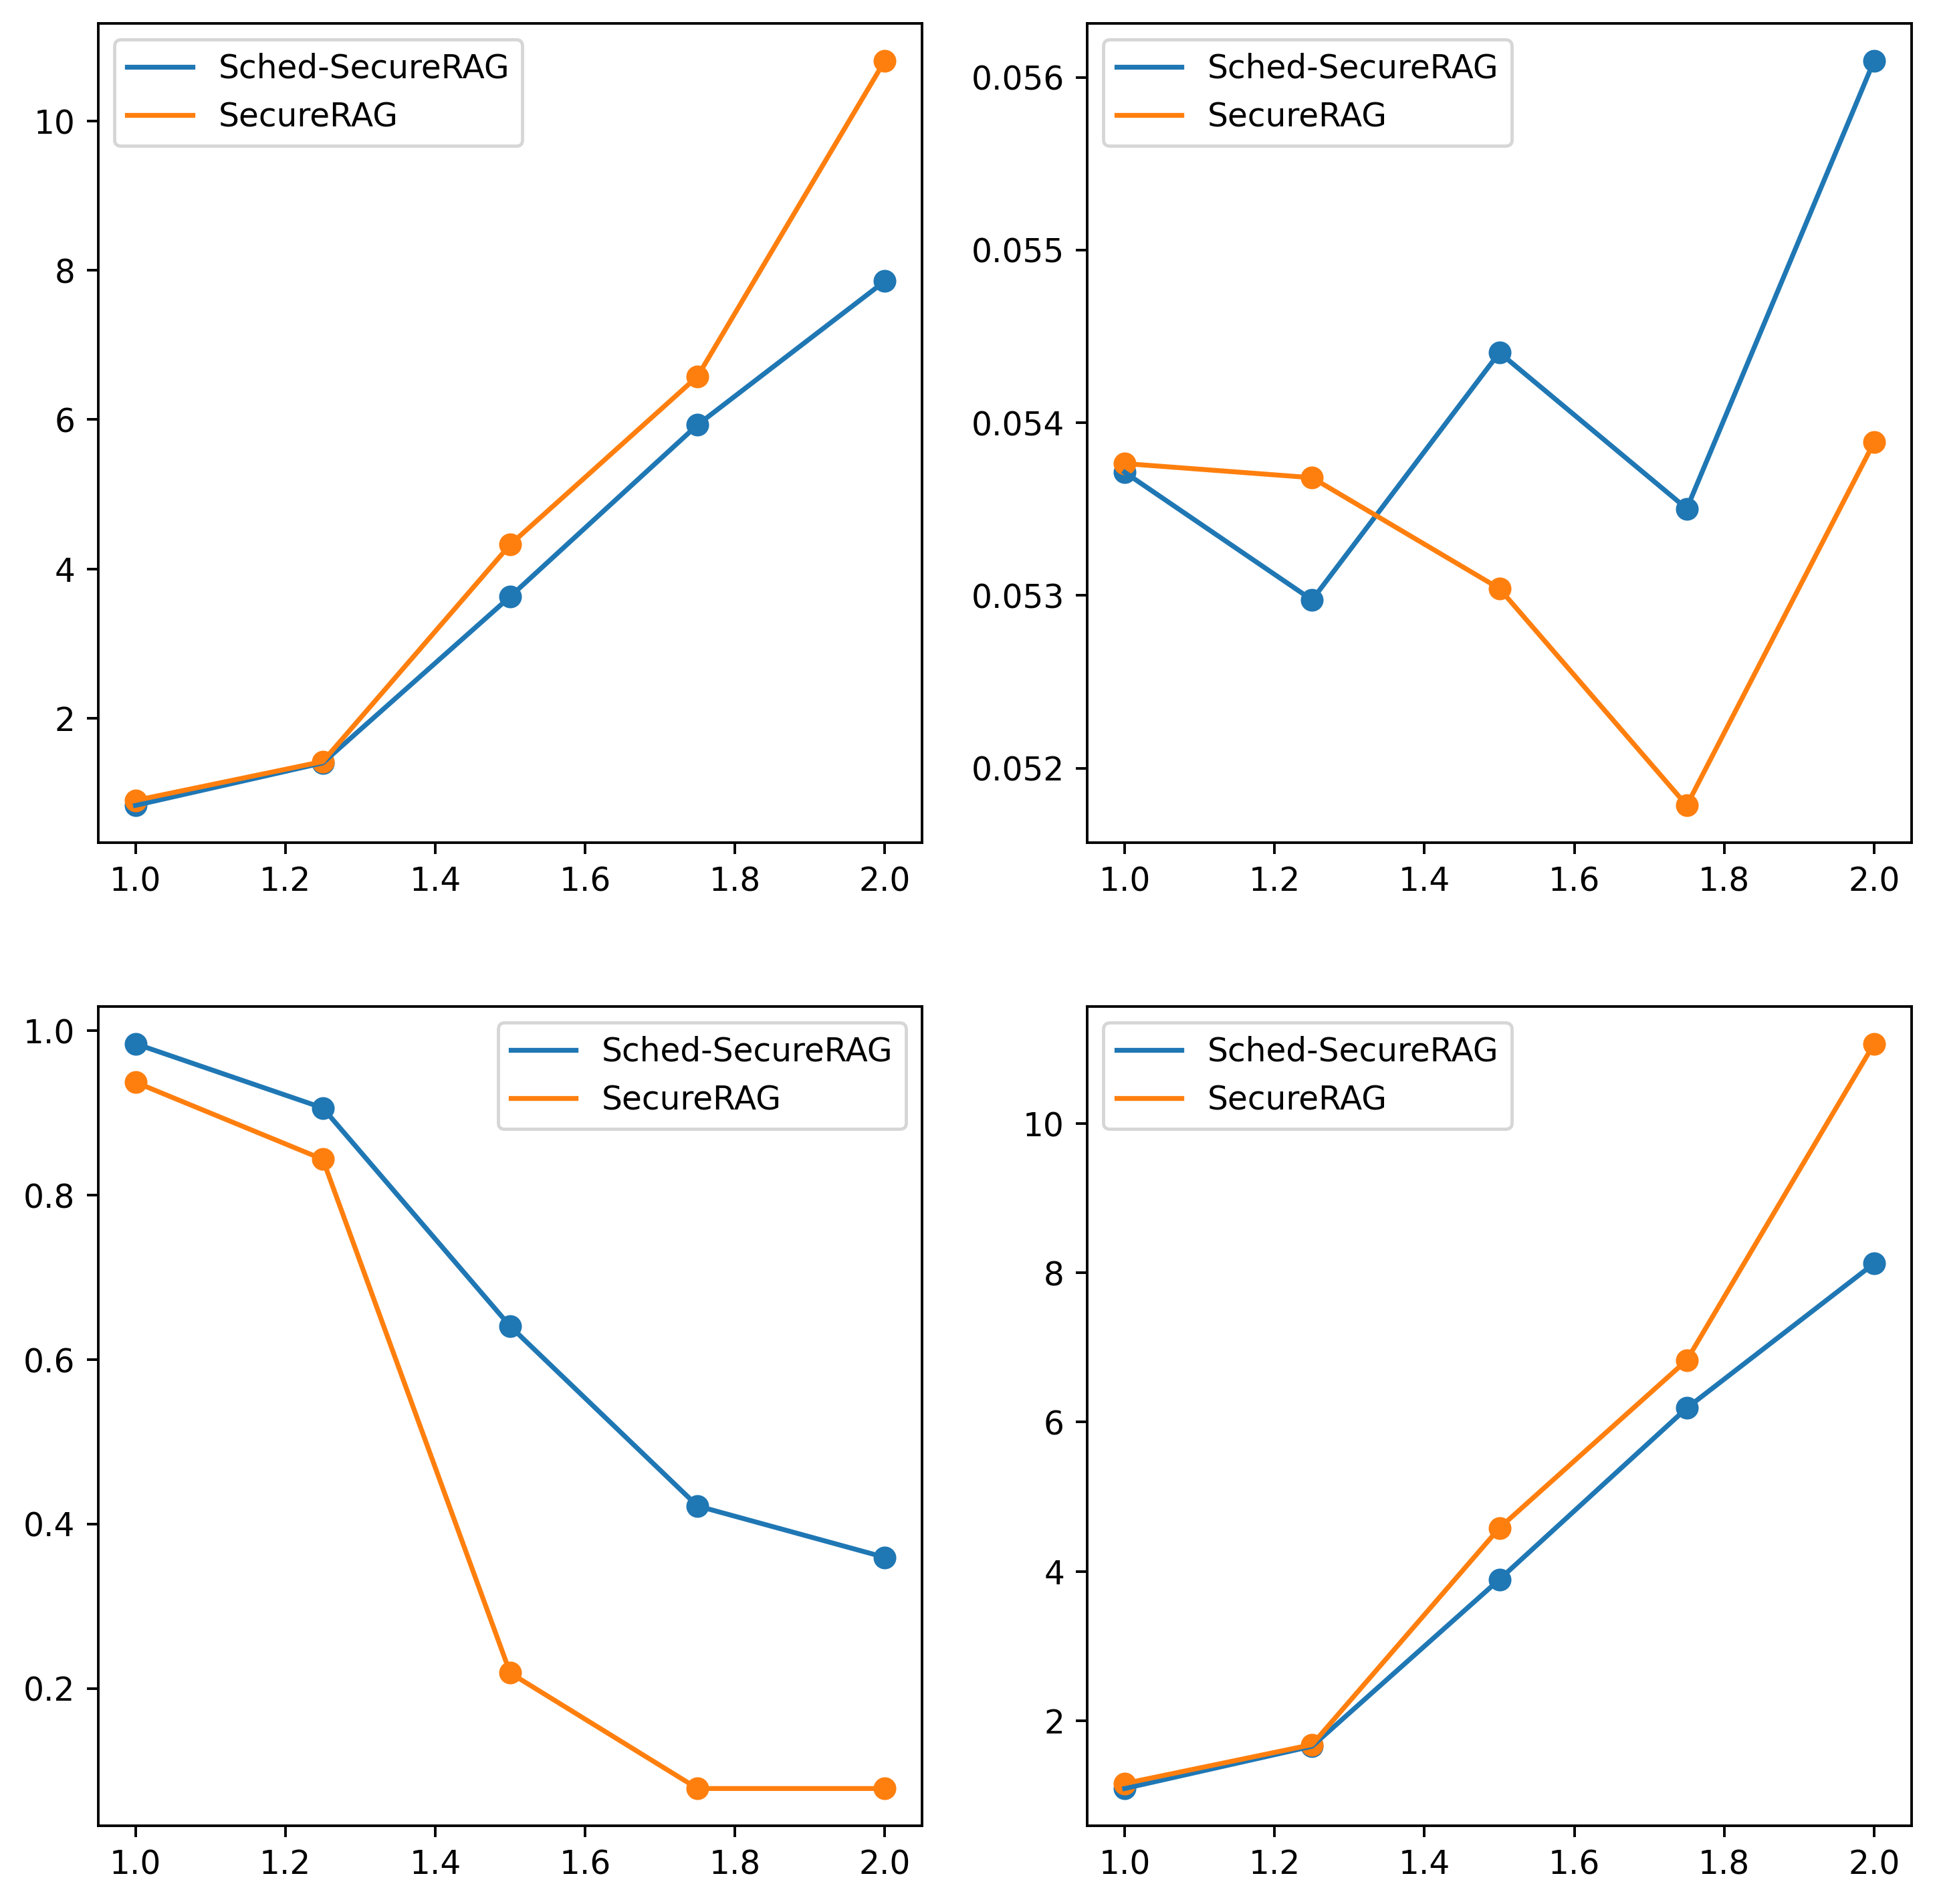

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=350)
for label, paths in zip(
    ["Sched-SecureRAG", "SecureRAG"], [sched_paths, offloading_paths]
):
    ttft = []
    tpot = []
    ttft_slo = []
    latency = []
    for idx, ratio in enumerate(req_ratios):
        metric = load_metric(paths[idx])
        ttft.append(metric["ttft"].mean())
        tpot.append(metric["tpot"].mean())
        latency.append(metric["latency"].mean())
        ttft_slo.append(metric["ttft_slo"].sum() / 64)
    x = req_ratios
    for y, y_label, ax in zip(
        [ttft, tpot, ttft_slo, latency],
        ["TTFT", "TPOT", "TTFT_SLO", "端到端 Latency"],
        axes.flatten(),
    ):
        ax.plot(x, y, label=label)
        ax.scatter(x, y)
        ax.legend()
        ax.xlabel("请求速率(req/s)")
        ax.ylabel(f"{y_label}(s)")